In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

Comparing the outputs from the FUTURES scenarios. From initial visual inspection, it is unclear that there is any difference between the three scenario outputs. 

In [ ]:
#load in the landuse outputs from the FUTURES model.
opt_path = r"C:\Users\klberge\Downloads\landuse_2038_Opt.tif"
base_path = r"C:\Users\klberge\Downloads\landuse_2038.tif"
pess_path = r"C:\Users\klberge\Downloads\landuse_2038_Pess.tif"
with rasterio.open(opt_path) as src:
    opt = src.read(1)
    profile = src.profile

with rasterio.open(base_path) as src:
    base = src.read(1)

with rasterio.open(pess_path) as src:
    pess = src.read(1)

In [5]:
print("Opt shape:", opt.shape)
print("Base shape:", base.shape)
print("Pess shape:", pess.shape)

Opt shape: (2650, 3060)
Base shape: (2650, 3060)
Pess shape: (2650, 3060)


In [ ]:
#False = same land use class as BAU map, 
#true = difference between scenario and BAU.
diff_opt_base = opt != base
diff_pess_base = pess != base
diff_opt_pess = opt != pess

In [ ]:
#CHECK IT'S DOING WHAT I THINK IT IS
print(diff_opt_base)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [7]:
all_diff = (opt != base) | (opt != pess) | (base != pess)

In [ ]:
#create empty rasster w/ same dims as land use 
change_map = np.zeros(base.shape)
#add a 1 where optimisitc scenario differs from BAU
change_map[(opt != base)] += 1
#add a 2 where pessimistic scenario differs from BAU
change_map[(pess != base)] += 2

#Three = when both opt differs from base scenario

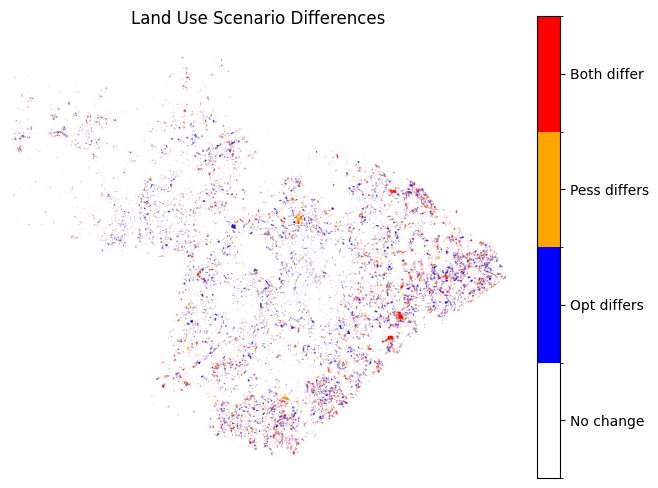

In [ ]:
import matplotlib.colors as colors

# Define colors for each difference type
cmap = colors.ListedColormap(['white', 'blue', 'orange', 'red'])

# Define boundaries
bounds = [-0.5,0.5,1.5,2.5,3.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

plt.figure(figsize=(8,6))
img = plt.imshow(change_map, cmap=cmap, norm=norm)

cbar = plt.colorbar(img, ticks=[0,1,2,3])
cbar.ax.set_yticklabels([
    "No change",
    "Opt differs",
    "Pess differs",
    "Both differ"
])

plt.title("Land Use Scenario Differences")
plt.axis("off")
plt.show()

In [ ]:
#quantify difference
total_pixels = base.size

opt_change = np.sum(opt != base) / total_pixels * 100
pess_change = np.sum(pess != base) / total_pixels * 100
opt_vs_pess = np.sum(opt != pess) / total_pixels * 100
opt_and_pess_vs_base = np.sum((opt != base) & (pess != base)) / total_pixels * 100

#get rseults to copy/paste
print(f"Opt vs BAU change: {opt_change:.2f}%")
print(f"Pess vs BAU change: {pess_change:.2f}%")
print(f"Opt vs Pess change: {opt_vs_pess:.2f}%")
print(f"Opt and Pess vs BAU change: {opt_and_pess_vs_base:.2f}%")

Opt vs BAU change: 2.32%
Pess vs BAU change: 1.68%
Opt vs Pess change: 2.13%
Opt and Pess vs BAU change: 0.93%


In [ ]:

# Get differences
diff_opt_base = (opt != base)
diff_pess_base = (pess != base)
#check
print(diff_pess_base)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


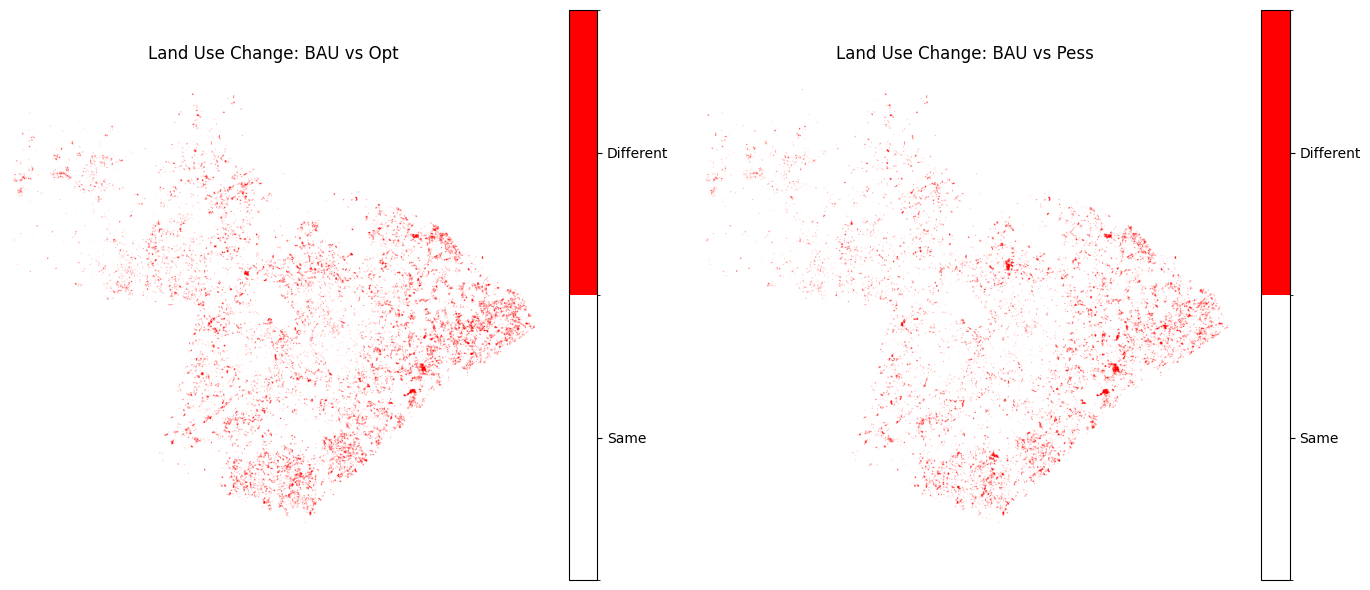

In [ ]:
plt.figure(figsize=(14, 6))

# Convert true/false
opt_change = diff_opt_base.astype(int)
pess_change = diff_pess_base.astype(int)

# Define colormap
cmap = colors.ListedColormap(['white', 'red'])
bounds = [-0.5, 0.5, 1.5]
norm = colors.BoundaryNorm(bounds, cmap.N)

# BAU vs Opt
plt.subplot(1, 2, 1)
img1 = plt.imshow(opt_change, cmap=cmap, norm=norm)
plt.title("Land Use Change: BAU vs Opt")
plt.axis("off")
cbar1 = plt.colorbar(img1, ticks=[0,1])
cbar1.ax.set_yticklabels(["Same","Different"])

# BAU vs Pess
plt.subplot(1, 2, 2)
img2 = plt.imshow(pess_change, cmap=cmap, norm=norm)
plt.title("Land Use Change: BAU vs Pess")
plt.axis("off")
cbar2 = plt.colorbar(img2, ticks=[0,1])
cbar2.ax.set_yticklabels(["Same","Different"])

plt.tight_layout()
plt.show()